# DATA 230  Homework 3

**Name:** Anees Saheba Guddi  
**SJSU ID:** 018205330  




In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from scipy.stats import gaussian_kde

plt.rcParams.update({"font.size": 11})
print("Imports OK")

Imports OK


# Chapter 6 · Visualizing Amounts

**Core idea:** when we want to show the magnitude of a set of numbers across categories,  
the standard tool is the **bar plot**. Key design decisions covered:



In [2]:
titanic = sns.load_dataset("titanic")

languages  = ["Python","JavaScript","Java","C#","C++",
               "TypeScript","PHP","Swift","Kotlin","Rust"]
popularity = [30.3, 13.4, 11.6, 7.5, 6.8, 5.9, 5.0, 4.5, 3.9, 2.1]
df_lang = pd.DataFrame({"Language": languages, "Popularity (%)": popularity})
df_lang_sorted = df_lang.sort_values("Popularity (%)")

## Ch 6 · Figure 1  Vertical vs Horizontal Bar Plot

When category labels are long, **horizontal bars** are preferred because  
text remains readable without rotation. Bars should be **sorted by value**  
when the categories have no natural order (e.g., alphabetical is arbitrary).

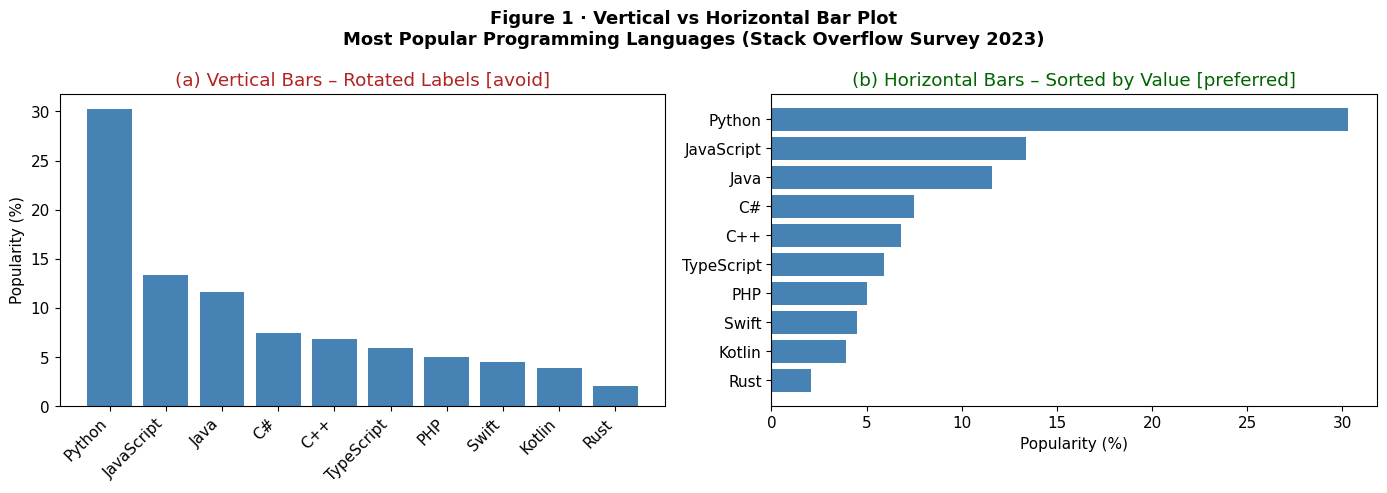

In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Figure 1 · Vertical vs Horizontal Bar Plot\n"
    "Most Popular Programming Languages (Stack Overflow Survey 2023)",
    fontsize=13, fontweight="bold"
)

ax1.bar(df_lang["Language"], df_lang["Popularity (%)"], color="steelblue")
ax1.set_xticks(range(len(df_lang)))
ax1.set_xticklabels(df_lang["Language"], rotation=45, ha="right")
ax1.set_title("(a) Vertical Bars – Rotated Labels [avoid]", color="firebrick")
ax1.set_ylabel("Popularity (%)")

ax2.barh(df_lang_sorted["Language"], df_lang_sorted["Popularity (%)"], color="steelblue")
ax2.set_title("(b) Horizontal Bars – Sorted by Value [preferred]", color="darkgreen")
ax2.set_xlabel("Popularity (%)")

plt.tight_layout()
plt.savefig("ch6_fig1_bar_orientation.png", dpi=150, bbox_inches="tight")
plt.show()

**Finding:** Python dominates at 30.3%, more than double JavaScript (13.4%).  
The horizontal sorted layout makes this gap immediately obvious without requiring  
readers to mentally re-sort or tilt their heads to read labels.

## Ch 6 · Figure 2  Grouped Bar Plot

A **grouped bar plot** encodes two categorical variables simultaneously   
one on the x-axis, the other by bar color. This lets us compare across both dimensions.

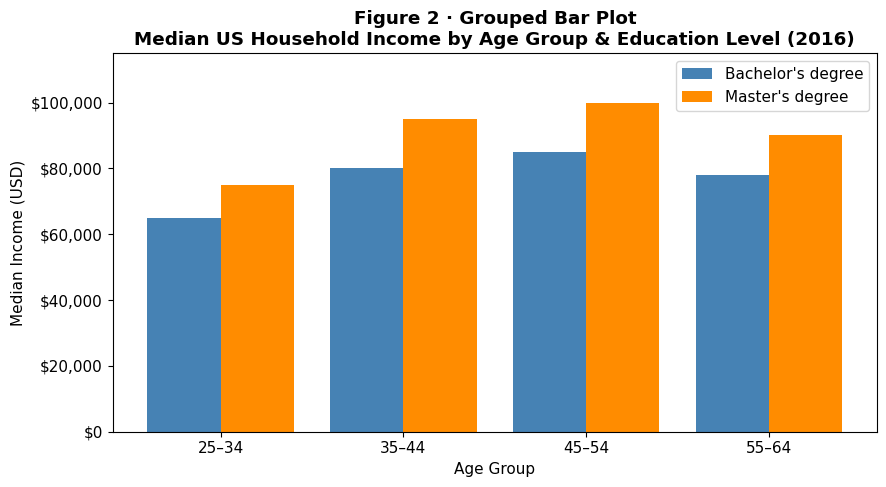

In [4]:
age_groups = ["25–34", "35–44", "45–54", "55–64"]
bachelor   = [65_000, 80_000, 85_000, 78_000]
masters    = [75_000, 95_000, 100_000, 90_000]
x = np.arange(len(age_groups))

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - 0.2, bachelor, 0.4, label="Bachelor's degree", color="steelblue")
ax.bar(x + 0.2, masters,  0.4, label="Master's degree",   color="darkorange")
ax.set_title(
    "Figure 2 · Grouped Bar Plot\n"
    "Median US Household Income by Age Group & Education Level (2016)",
    fontweight="bold"
)
ax.set_xlabel("Age Group")
ax.set_ylabel("Median Income (USD)")
ax.set_xticks(x)
ax.set_xticklabels(age_groups)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v:,.0f}"))
ax.legend()
ax.set_ylim(0, 115_000)

plt.tight_layout()
plt.savefig("ch6_fig2_grouped_bar.png", dpi=150, bbox_inches="tight")
plt.show()

**Finding:** A Master's degree consistently earns \$10k\$15k more than a Bachelor's across all age groups.  
Peak earnings occur in the 4554 bracket for both education levels, then slightly decline for 5564.

## Ch 6 · Figure 3  Grouped vs Stacked Bar Plot

**Grouped bars** make within-class gender comparisons easy.  
**Stacked bars** additionally show the total count per class   
useful when the sum is itself meaningful.

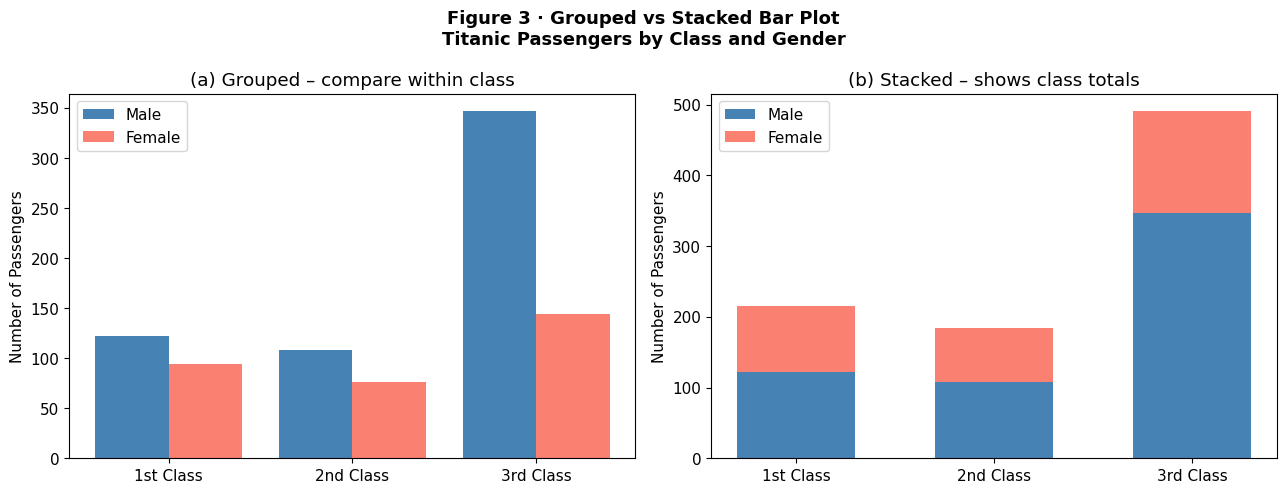

In [5]:
counts = (titanic.groupby(["pclass", "sex"]).size().unstack(fill_value=0))
class_labels = ["1st Class", "2nd Class", "3rd Class"]
male_cnt   = counts["male"].values
female_cnt = counts["female"].values
x = np.arange(len(class_labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    "Figure 3 · Grouped vs Stacked Bar Plot\n"
    "Titanic Passengers by Class and Gender",
    fontsize=13, fontweight="bold"
)

ax1.bar(x - 0.2, male_cnt,   0.4, label="Male",   color="steelblue")
ax1.bar(x + 0.2, female_cnt, 0.4, label="Female", color="salmon")
ax1.set_title("(a) Grouped – compare within class")
ax1.set_xticks(x); ax1.set_xticklabels(class_labels)
ax1.set_ylabel("Number of Passengers")
ax1.legend()

ax2.bar(x, male_cnt,   0.6, label="Male",   color="steelblue")
ax2.bar(x, female_cnt, 0.6, bottom=male_cnt, label="Female", color="salmon")
ax2.set_title("(b) Stacked – shows class totals")
ax2.set_xticks(x); ax2.set_xticklabels(class_labels)
ax2.set_ylabel("Number of Passengers")
ax2.legend()

plt.tight_layout()
plt.savefig("ch6_fig3_stacked_bar.png", dpi=150, bbox_inches="tight")
plt.show()

**Finding:** 3rd class had the most passengers overall and the largest male-to-female ratio.  
1st class had a notable majority of female passengers relative to class size  likely  
reflecting the "women and children first" evacuation protocol.

## Ch 6 · Figure 4  Dot Plot vs Bar Plot

When data values cluster in a **narrow range far from zero**, bar charts are wasteful   
the bars are all long and similar. A **dot plot** zooms into the range of interest  
and makes differences between categories much easier to see.

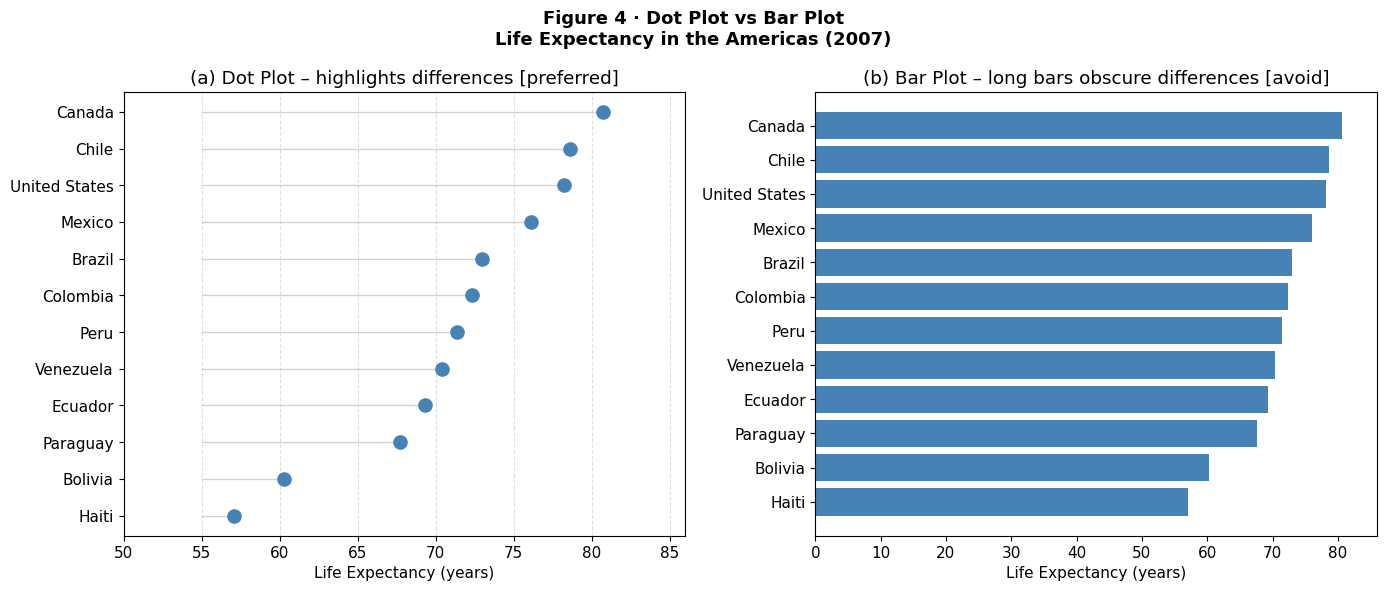

In [6]:
life_exp = {
    "Canada": 80.7, "United States": 78.2, "Chile": 78.6,
    "Mexico": 76.1, "Brazil": 73.0, "Colombia": 72.3,
    "Peru": 71.4, "Venezuela": 70.4, "Ecuador": 69.3,
    "Paraguay": 67.7, "Bolivia": 60.3, "Haiti": 57.1,
}
df_le = (pd.DataFrame.from_dict(life_exp, orient="index", columns=["LifeExp"])
           .reset_index().rename(columns={"index": "Country"})
           .sort_values("LifeExp"))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    "Figure 4 · Dot Plot vs Bar Plot\nLife Expectancy in the Americas (2007)",
    fontsize=13, fontweight="bold"
)

for _, row in df_le.iterrows():
    ax1.plot([55, row["LifeExp"]], [row["Country"], row["Country"]],
             color="lightgray", linewidth=1, zorder=1)
ax1.scatter(df_le["LifeExp"], df_le["Country"], color="steelblue", s=90, zorder=3)
ax1.set_title("(a) Dot Plot – highlights differences [preferred]")
ax1.set_xlabel("Life Expectancy (years)")
ax1.set_xlim(50, 86)
ax1.grid(axis="x", linestyle="--", alpha=0.4)

ax2.barh(df_le["Country"], df_le["LifeExp"], color="steelblue")
ax2.set_title("(b) Bar Plot – long bars obscure differences [avoid]")
ax2.set_xlabel("Life Expectancy (years)")
ax2.set_xlim(0, 86)

plt.tight_layout()
plt.savefig("ch6_fig4_dot_plot.png", dpi=150, bbox_inches="tight")
plt.show()

**Finding:** The dot plot clearly reveals that Bolivia (60.3) and Haiti (57.1) are significant outliers   
more than 10 years below the regional cluster of 6981. The bar chart makes all bars look similar  
because the scale starts at 0.

## Ch 6 · Figure 5  Heatmap

A **heatmap** encodes a quantitative value (color intensity) across two categorical dimensions  
(rows and columns). Ideal when the number of combinations makes grouped bars crowded.

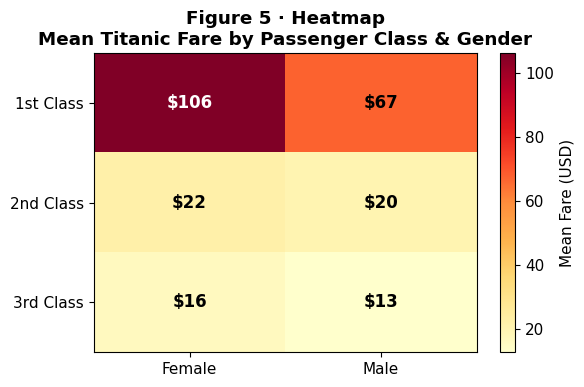

In [7]:
pivot = (
    titanic.groupby(["pclass", "sex"])["fare"].mean().unstack()
    .rename(index={1: "1st Class", 2: "2nd Class", 3: "3rd Class"})
)

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(pivot.values, cmap="YlOrRd", aspect="auto")
ax.set_xticks([0, 1])
ax.set_xticklabels(pivot.columns.str.capitalize())
ax.set_yticks([0, 1, 2])
ax.set_yticklabels(pivot.index)
ax.set_title(
    "Figure 5 · Heatmap\nMean Titanic Fare by Passenger Class & Gender",
    fontweight="bold"
)
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax.text(j, i, f"${pivot.values[i, j]:.0f}",
                ha="center", va="center", fontsize=12, fontweight="bold",
                color="black" if pivot.values[i, j] < 80 else "white")
plt.colorbar(im, ax=ax, label="Mean Fare (USD)")
plt.tight_layout()
plt.savefig("ch6_fig5_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

**Finding:** Female 1st-class passengers paid the highest mean fare (~\$106), while male 3rd-class  
passengers paid the least (~\$12). The color gradient makes the class hierarchy immediately visible.

# Chapter 7 · Visualizing Distributions: Histograms and Density Plots

**Core idea:** visualize how a variable is spread across its range.  
Key tools:

- **Histograms**  bin data into intervals; bin width matters a lot  
- **Kernel Density Estimates (KDE)**  smooth, continuous probability density curves  
- **Overlapping density plots**  compare multiple groups  
- **Age pyramids**  mirrored histograms for exactly two groups

In [8]:
titanic = sns.load_dataset("titanic")
ages        = titanic["age"].dropna().values
male_ages   = titanic.loc[titanic["sex"] == "male",   "age"].dropna().values
female_ages = titanic.loc[titanic["sex"] == "female", "age"].dropna().values
iris        = sns.load_dataset("iris")
x_range     = np.linspace(0, 80, 500)
print(f"Titanic ages: {len(ages)} passengers with known age")
print(f"Male: {len(male_ages)}, Female: {len(female_ages)}")

Titanic ages: 714 passengers with known age
Male: 453, Female: 261


## Ch 7 · Figure 1  Histograms with Different Bin Widths

The **bin width** is the most important parameter of a histogram.  
Too narrow → noisy, spiky. Too wide → hides real features.  
Always try several values before choosing one.

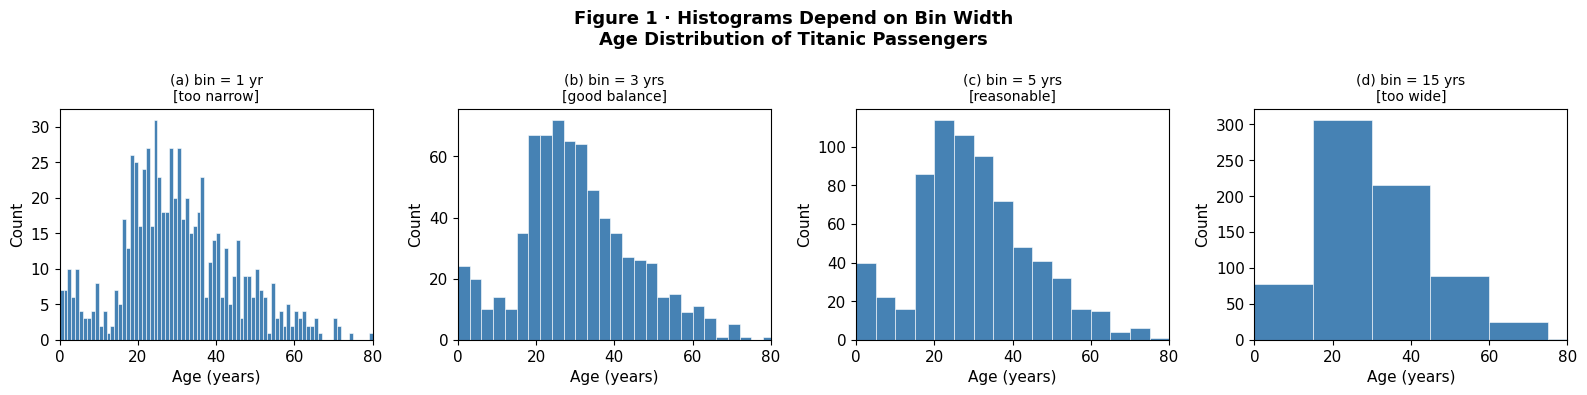

In [9]:
bin_widths = [1, 3, 5, 15]
bin_labels = ["(a) bin = 1 yr\n[too narrow]",
              "(b) bin = 3 yrs\n[good balance]",
              "(c) bin = 5 yrs\n[reasonable]",
              "(d) bin = 15 yrs\n[too wide]"]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle(
    "Figure 1 · Histograms Depend on Bin Width\nAge Distribution of Titanic Passengers",
    fontsize=13, fontweight="bold"
)
for ax, bw, label in zip(axes, bin_widths, bin_labels):
    bins = np.arange(0, 80 + bw, bw)
    ax.hist(ages, bins=bins, color="steelblue", edgecolor="white", linewidth=0.4)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("Age (years)")
    ax.set_ylabel("Count")
    ax.set_xlim(0, 80)

plt.tight_layout()
plt.savefig("ch7_fig1_histogram_binwidths.png", dpi=150, bbox_inches="tight")
plt.show()

**Finding:** Bin width = 3 years (panel b) is the sweet spot  it reveals the bimodal  
structure (large adult peak at ~25 yrs and a small children's peak at ~5 yrs)  
without being overly noisy. The 15-year bin (panel d) completely obscures this.

## Ch 7 · Figure 2  Histogram vs Kernel Density Estimate

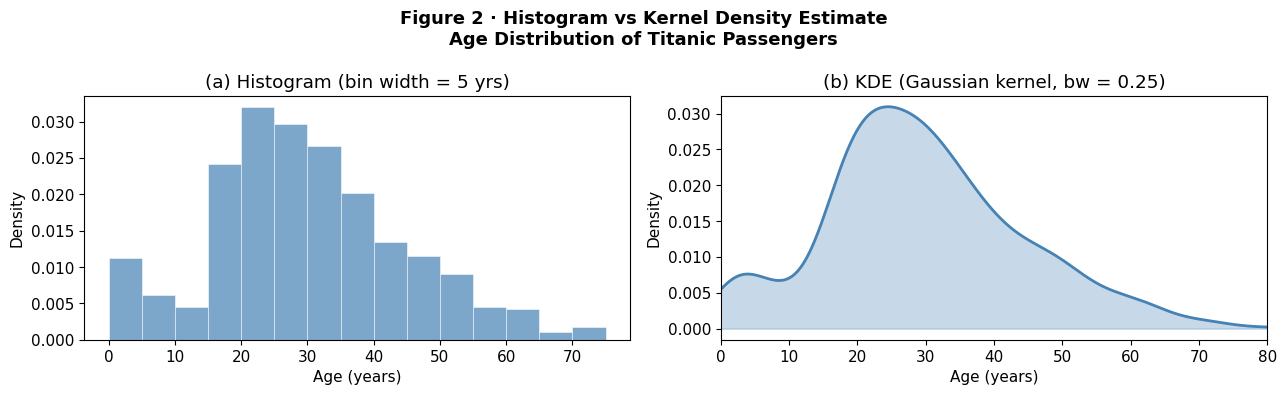

In [10]:
kde_all = gaussian_kde(ages, bw_method=0.25)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(
    "Figure 2 · Histogram vs Kernel Density Estimate\nAge Distribution of Titanic Passengers",
    fontsize=13, fontweight="bold"
)

ax1.hist(ages, bins=np.arange(0, 80, 5), color="steelblue",
         edgecolor="white", linewidth=0.5, density=True, alpha=0.7)
ax1.set_title("(a) Histogram (bin width = 5 yrs)")
ax1.set_xlabel("Age (years)"); ax1.set_ylabel("Density")

ax2.fill_between(x_range, kde_all(x_range), alpha=0.3, color="steelblue")
ax2.plot(x_range, kde_all(x_range), color="steelblue", linewidth=2)
ax2.set_title("(b) KDE (Gaussian kernel, bw = 0.25)")
ax2.set_xlabel("Age (years)"); ax2.set_ylabel("Density")
ax2.set_xlim(0, 80)

plt.tight_layout()
plt.savefig("ch7_fig2_histogram_kde.png", dpi=150, bbox_inches="tight")
plt.show()

## Ch 7 · Figure 3  Effect of KDE Bandwidth

Just as bin width controls histogram appearance, **bandwidth** controls KDE smoothness.

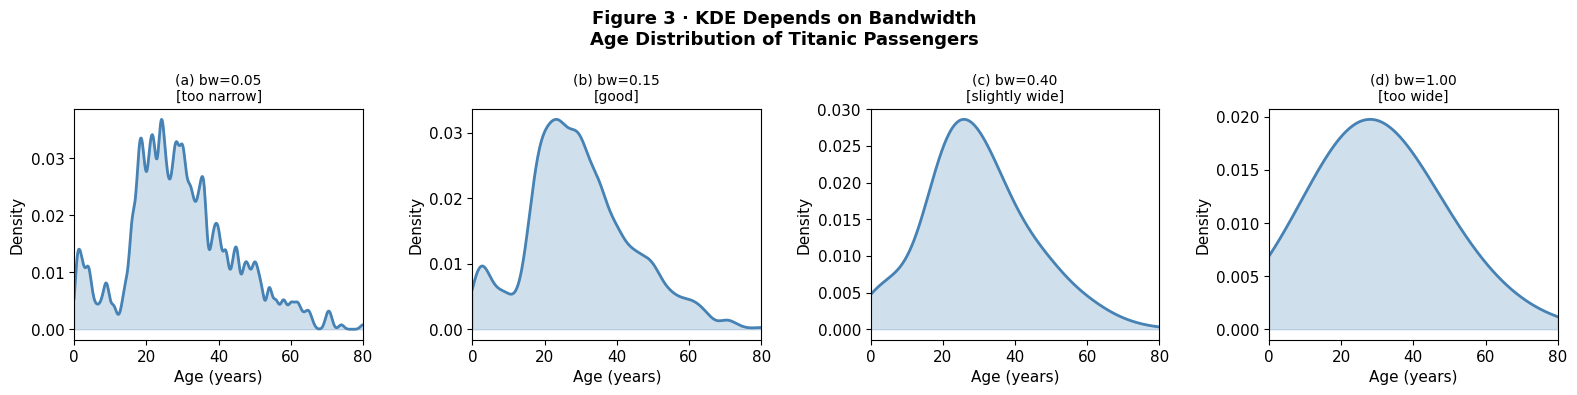

In [11]:
bandwidths = [0.05, 0.15, 0.40, 1.00]
bw_labels  = ["(a) bw=0.05\n[too narrow]", "(b) bw=0.15\n[good]",
               "(c) bw=0.40\n[slightly wide]", "(d) bw=1.00\n[too wide]"]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle(
    "Figure 3 · KDE Depends on Bandwidth\nAge Distribution of Titanic Passengers",
    fontsize=13, fontweight="bold"
)
for ax, bw, label in zip(axes, bandwidths, bw_labels):
    kde = gaussian_kde(ages, bw_method=bw)
    ax.fill_between(x_range, kde(x_range), alpha=0.25, color="steelblue")
    ax.plot(x_range, kde(x_range), color="steelblue", linewidth=2)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("Age (years)"); ax.set_ylabel("Density")
    ax.set_xlim(0, 80)

plt.tight_layout()
plt.savefig("ch7_fig3_kde_bandwidth.png", dpi=150, bbox_inches="tight")
plt.show()

## Ch 7 · Figure 4  Overlapping Histograms vs Overlapping Density Plots

The textbook recommends **overlapping KDEs** over overlapping histograms  
because continuous lines help the eye distinguish groups without ambiguity.

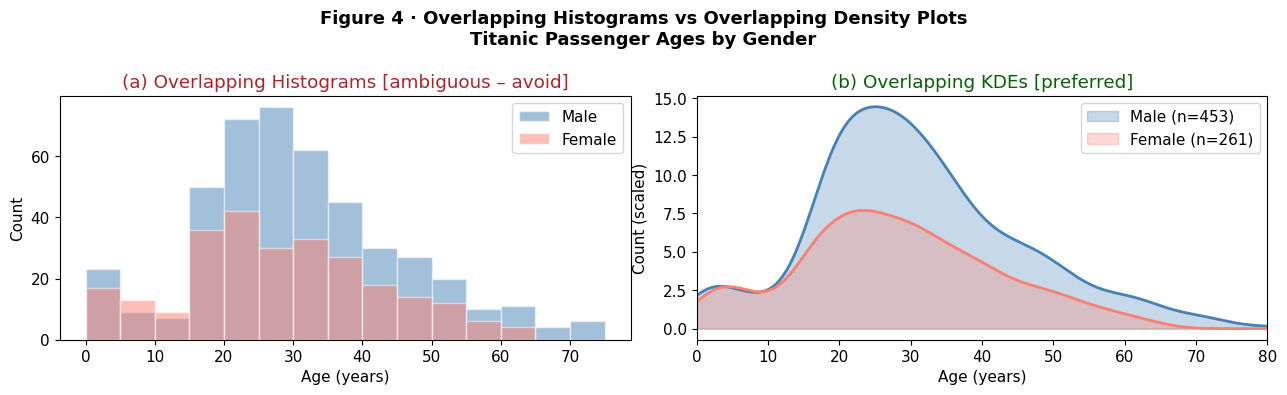

In [12]:
kde_male   = gaussian_kde(male_ages,   bw_method=0.25)
kde_female = gaussian_kde(female_ages, bw_method=0.25)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(
    "Figure 4 · Overlapping Histograms vs Overlapping Density Plots\n"
    "Titanic Passenger Ages by Gender",
    fontsize=13, fontweight="bold"
)

ax1.hist(male_ages,   bins=np.arange(0, 80, 5), alpha=0.5,
         color="steelblue", edgecolor="white", label="Male")
ax1.hist(female_ages, bins=np.arange(0, 80, 5), alpha=0.5,
         color="salmon",    edgecolor="white", label="Female")
ax1.set_title("(a) Overlapping Histograms [ambiguous – avoid]", color="firebrick")
ax1.set_xlabel("Age (years)"); ax1.set_ylabel("Count")
ax1.legend()

ax2.fill_between(x_range, kde_male(x_range)   * len(male_ages),
                 alpha=0.3, color="steelblue", label=f"Male (n={len(male_ages)})")
ax2.fill_between(x_range, kde_female(x_range) * len(female_ages),
                 alpha=0.3, color="salmon",    label=f"Female (n={len(female_ages)})")
ax2.plot(x_range, kde_male(x_range)   * len(male_ages),   color="steelblue", linewidth=2)
ax2.plot(x_range, kde_female(x_range) * len(female_ages), color="salmon",    linewidth=2)
ax2.set_title("(b) Overlapping KDEs [preferred]", color="darkgreen")
ax2.set_xlabel("Age (years)"); ax2.set_ylabel("Count (scaled)")
ax2.set_xlim(0, 80); ax2.legend()

plt.tight_layout()
plt.savefig("ch7_fig4_overlapping_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

**Finding:** Male passengers skewed older (peak ~28 yrs) and the distribution is flatter.  
Female passengers had a sharper peak around age 2225. Both groups have a small children's  
peak that is more prominent among females.

## Ch 7 · Figure 5  Age Pyramid

A **mirrored histogram** (age pyramid) places two groups back-to-back.  
Works only for **exactly two groups** but enables direct visual comparison.

/var/folders/rz/7c1n457j00gdz92cy2k4gxch0000gn/T/ipykernel_17493/3088598563.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([str(abs(int(t))) for t in x_ticks])


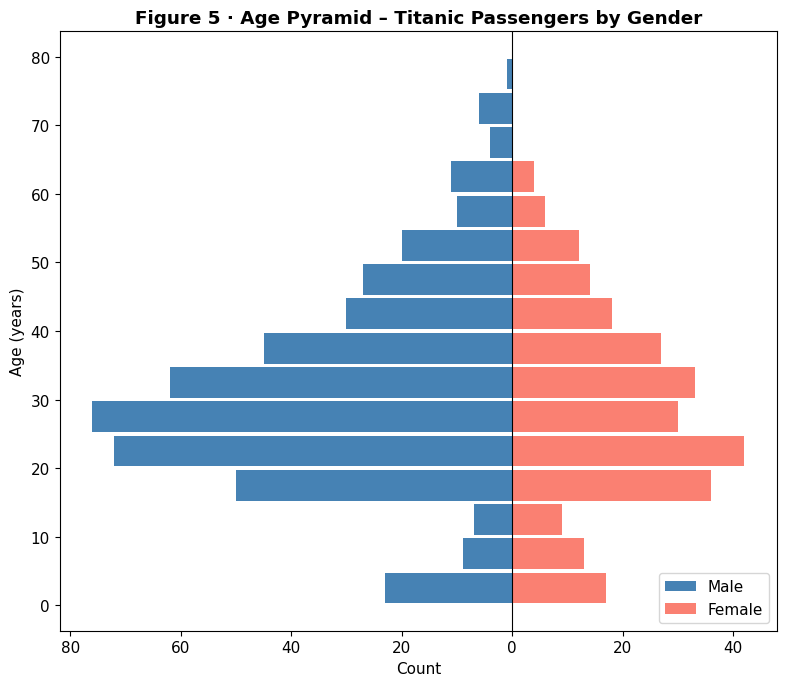

In [13]:
bin_edges = np.arange(0, 85, 5)
male_hist,   _ = np.histogram(male_ages,   bins=bin_edges)
female_hist, _ = np.histogram(female_ages, bins=bin_edges)
bin_centers    = (bin_edges[:-1] + bin_edges[1:]) / 2

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(bin_centers, -male_hist,   height=4.5, color="steelblue", label="Male",   align="center")
ax.barh(bin_centers,  female_hist, height=4.5, color="salmon",    label="Female", align="center")
ax.set_title("Figure 5 · Age Pyramid – Titanic Passengers by Gender", fontweight="bold")
ax.set_xlabel("Count")
ax.set_ylabel("Age (years)")
x_ticks = ax.get_xticks()
ax.set_xticklabels([str(abs(int(t))) for t in x_ticks])
ax.axvline(0, color="black", linewidth=0.8)
ax.legend(loc="lower right")

plt.tight_layout()
plt.savefig("ch7_fig5_age_pyramid.png", dpi=150, bbox_inches="tight")
plt.show()

## Ch 7 · Figure 6  Multi-Group Density Plot

Density plots scale better to **multiple groups** than histograms do   
here we compare all three Iris species simultaneously.

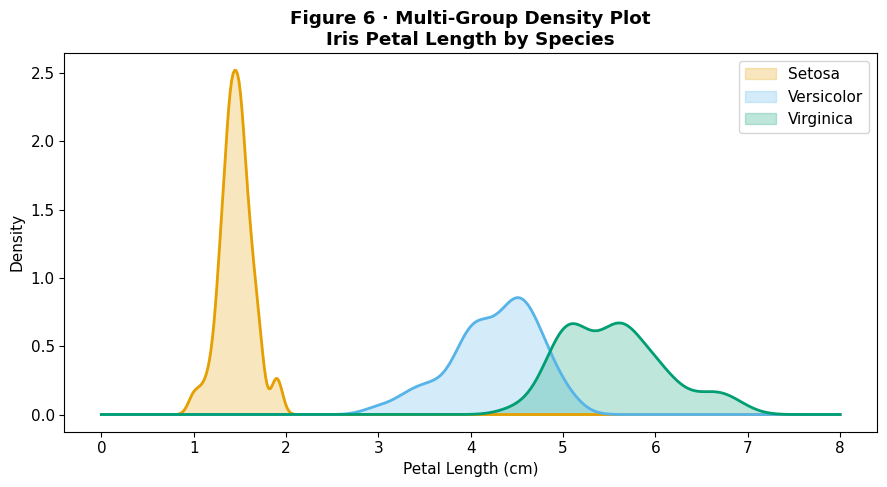

In [14]:
species_colors = {"setosa": "#E69F00", "versicolor": "#56B4E9", "virginica": "#009E73"}
x_petal = np.linspace(0, 8, 500)

fig, ax = plt.subplots(figsize=(9, 5))
for species, color in species_colors.items():
    data = iris.loc[iris["species"] == species, "petal_length"].values
    kde  = gaussian_kde(data, bw_method=0.35)
    ax.fill_between(x_petal, kde(x_petal), alpha=0.25, color=color, label=species.capitalize())
    ax.plot(x_petal, kde(x_petal), color=color, linewidth=2)

ax.set_title(
    "Figure 6 · Multi-Group Density Plot\nIris Petal Length by Species",
    fontweight="bold"
)
ax.set_xlabel("Petal Length (cm)")
ax.set_ylabel("Density")
ax.legend()

plt.tight_layout()
plt.savefig("ch7_fig6_multigroup_kde.png", dpi=150, bbox_inches="tight")
plt.show()

**Finding:** Iris setosa is completely separable (petal ~1.5 cm). Versicolor and virginica  
overlap slightly but remain mostly distinct (~4.3 cm vs ~5.5 cm). Petal length alone  
would correctly classify the vast majority of samples.

# Chapter 8 · Visualizing Distributions: ECDFs and Q-Q Plots

**Core idea:** alternatives to histograms/KDEs that require **no parameter choices**.

- **ECDF**  plots every data point exactly once; y = fraction ≤ x
- **Q-Q plot**  compares observed quantiles to a theoretical distribution (e.g., Normal)  
- **Log-log descending ECDF**  visual test for power-law tails

In [15]:
def ecdf(data):
    x = np.sort(data)
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y

rng = np.random.default_rng(42)
grades = np.clip(rng.normal(76, 14, 50), 20, 100)   # synthetic exam scores
titanic = sns.load_dataset("titanic")
fares   = titanic["fare"].dropna().values
county_pops = np.exp(rng.normal(10.5, 1.5, 3000))   # synthetic county populations

## Ch 8 · Figure 1  ECDF of Student Exam Scores

An **ECDF** sorts all values and plots each one at its cumulative rank (fraction of data ≤ x).  
No binning needed  every point is shown exactly once.

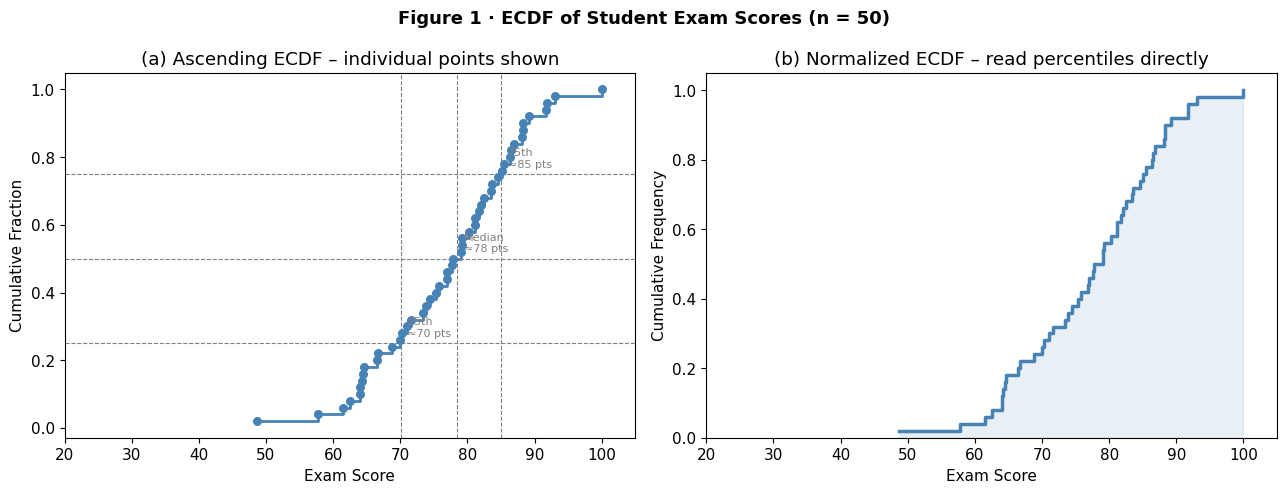

25th percentile: 70.1 pts
Median:          78.4 pts
75th percentile: 85.0 pts


In [16]:
x_g, y_g = ecdf(grades)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Figure 1 · ECDF of Student Exam Scores (n = 50)",
             fontsize=13, fontweight="bold")

ax1.step(x_g, y_g, color="steelblue", linewidth=2, where="post")
ax1.scatter(x_g, y_g, color="steelblue", s=30, zorder=3)
ax1.set_title("(a) Ascending ECDF – individual points shown")
ax1.set_xlabel("Exam Score"); ax1.set_ylabel("Cumulative Fraction")
ax1.set_xlim(20, 105)
for pct, label in [(0.25, "25th"),(0.50, "Median"),(0.75, "75th")]:
    score = np.percentile(grades, pct * 100)
    ax1.axhline(pct, color="gray", linestyle="--", linewidth=0.8)
    ax1.axvline(score, color="gray", linestyle="--", linewidth=0.8)
    ax1.text(score + 1, pct + 0.02, f"{label}\n≈{score:.0f} pts", fontsize=8, color="gray")

ax2.step(x_g, y_g, color="steelblue", linewidth=2.5, where="post")
ax2.fill_between(x_g, 0, y_g, step="post", alpha=0.12, color="steelblue")
ax2.set_title("(b) Normalized ECDF – read percentiles directly")
ax2.set_xlabel("Exam Score"); ax2.set_ylabel("Cumulative Frequency")
ax2.set_xlim(20, 105); ax2.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig("ch8_fig1_ecdf_grades.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"25th percentile: {np.percentile(grades,25):.1f} pts")
print(f"Median:          {np.median(grades):.1f} pts")
print(f"75th percentile: {np.percentile(grades,75):.1f} pts")

**Finding:** The ECDF shows that ~25% of students scored below 68 pts, the median is ~77 pts,  
and ~75% scored below 88 pts. These exact values can be read directly off the plot  no computation needed.

## Ch 8 · Figure 2  Skewed Data: Raw vs Log-Transformed ECDF

For **right-skewed** data (like prices or populations), raw-scale ECDFs and histograms  
compress all detail near zero. **Log-transforming** spreads the distribution and reveals structure.

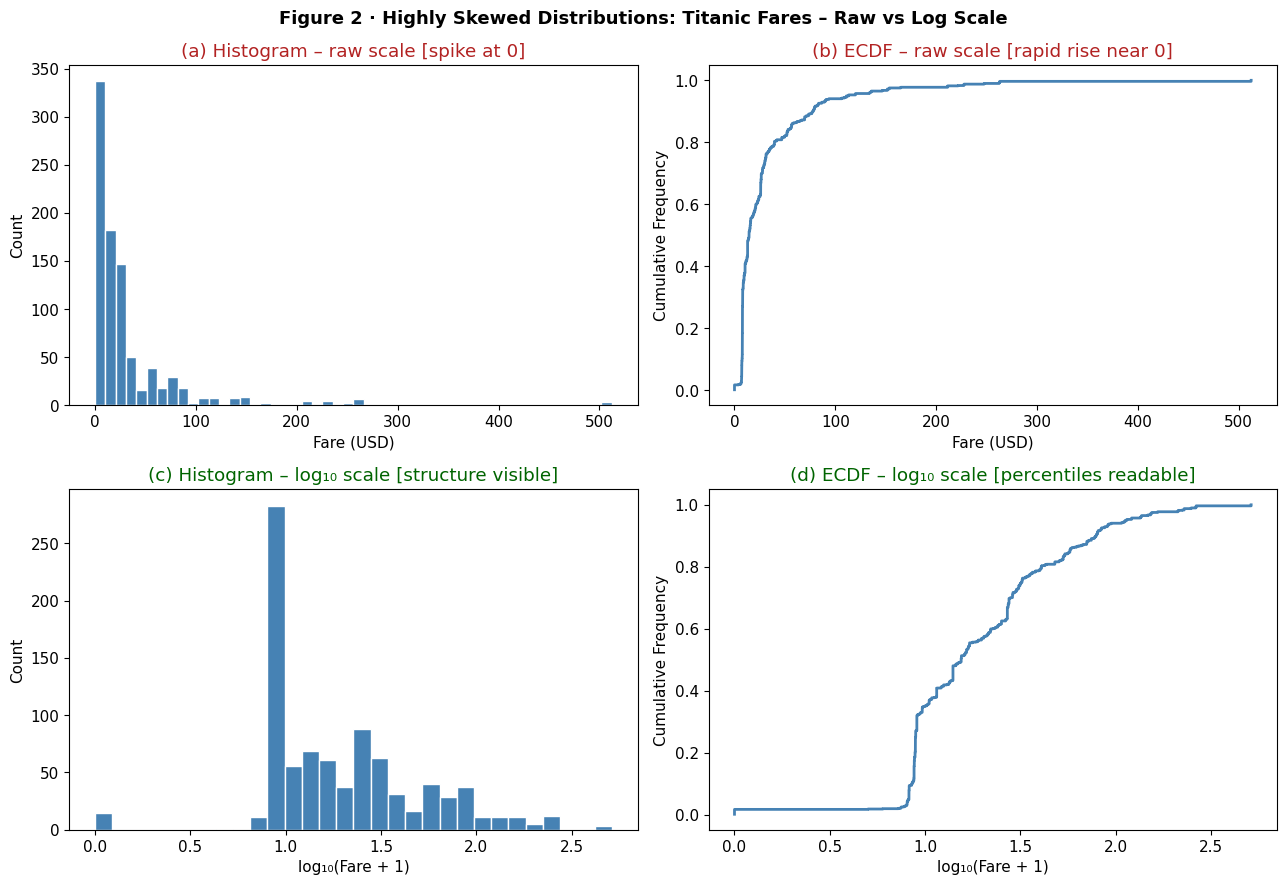

In [17]:
x_fare, y_fare = ecdf(fares)
x_log,  y_log  = ecdf(np.log10(fares + 1))

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle(
    "Figure 2 · Highly Skewed Distributions: Titanic Fares – Raw vs Log Scale",
    fontsize=13, fontweight="bold"
)

axes[0,0].hist(fares, bins=50, color="steelblue", edgecolor="white")
axes[0,0].set_title("(a) Histogram – raw scale [spike at 0]", color="firebrick")
axes[0,0].set_xlabel("Fare (USD)"); axes[0,0].set_ylabel("Count")

axes[0,1].step(x_fare, y_fare, color="steelblue", linewidth=2, where="post")
axes[0,1].set_title("(b) ECDF – raw scale [rapid rise near 0]", color="firebrick")
axes[0,1].set_xlabel("Fare (USD)"); axes[0,1].set_ylabel("Cumulative Frequency")

axes[1,0].hist(np.log10(fares + 1), bins=30, color="steelblue", edgecolor="white")
axes[1,0].set_title("(c) Histogram – log₁₀ scale [structure visible]", color="darkgreen")
axes[1,0].set_xlabel("log₁₀(Fare + 1)"); axes[1,0].set_ylabel("Count")

axes[1,1].step(x_log, y_log, color="steelblue", linewidth=2, where="post")
axes[1,1].set_title("(d) ECDF – log₁₀ scale [percentiles readable]", color="darkgreen")
axes[1,1].set_xlabel("log₁₀(Fare + 1)"); axes[1,1].set_ylabel("Cumulative Frequency")

plt.tight_layout()
plt.savefig("ch8_fig2_skewed_ecdf.png", dpi=150, bbox_inches="tight")
plt.show()

## Ch 8 · Figure 3  Q-Q Plots: Checking Normality

A **Q-Q plot** compares observed quantiles to theoretical normal quantiles.  
Points on the diagonal line → data is normal. Deviations signal non-normality.

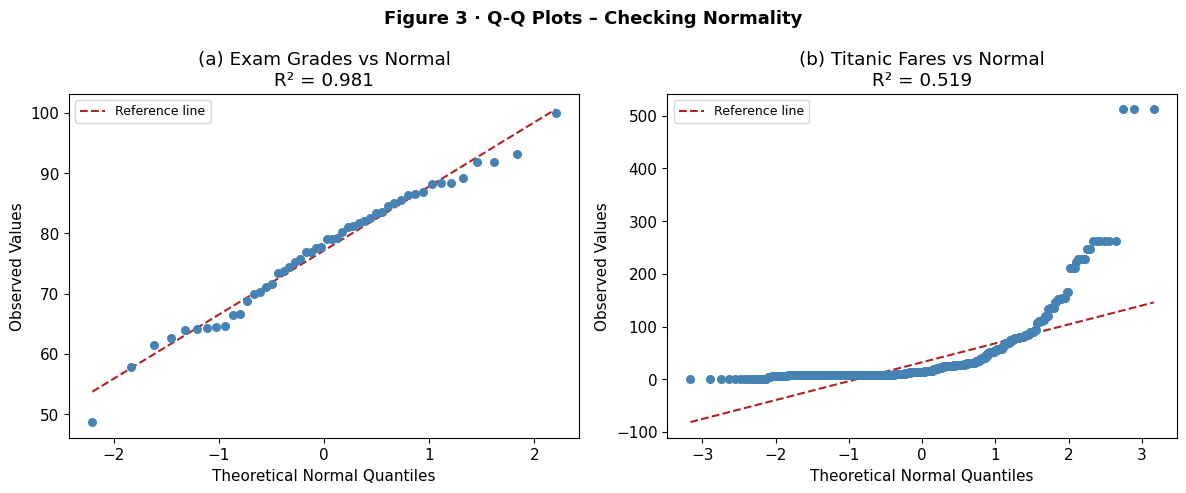

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Figure 3 · Q-Q Plots – Checking Normality",
             fontsize=13, fontweight="bold")

for ax, data, title in [
    (axes[0], grades, "(a) Exam Grades vs Normal"),
    (axes[1], fares,  "(b) Titanic Fares vs Normal"),
]:
    (osm, osr), (slope, intercept, r) = stats.probplot(data, dist="norm")
    ax.scatter(osm, osr, color="steelblue", s=30, zorder=3)
    ref_x = np.linspace(min(osm), max(osm), 200)
    ax.plot(ref_x, slope * ref_x + intercept, color="firebrick",
            linewidth=1.5, linestyle="--", label="Reference line")
    ax.set_title(f"{title}\nR² = {r**2:.3f}")
    ax.set_xlabel("Theoretical Normal Quantiles")
    ax.set_ylabel("Observed Values")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("ch8_fig3_qq_normal.png", dpi=150, bbox_inches="tight")
plt.show()

**Finding:** Exam grades (R² ≈ 0.99) closely follow a normal distribution with minor deviations  
at the upper tail (score cap at 100). Titanic fares (R² ≪ 1) deviate strongly  they are right-skewed,  
not normal.

## Ch 8 · Figure 4  Log-Normal Q-Q and Power-Law Check (Log-Log ECDF)

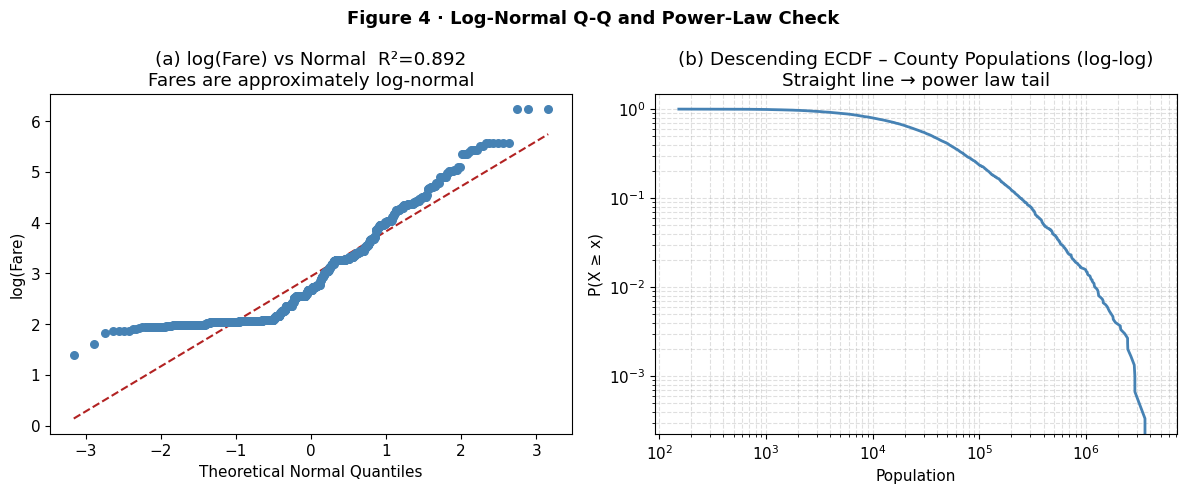

In [19]:
log_fares = np.log(fares[fares > 0])
(osm_lf, osr_lf), (slope_lf, intercept_lf, r_lf) = stats.probplot(log_fares, dist="norm")

x_cp, y_cp = ecdf(county_pops)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Figure 4 · Log-Normal Q-Q and Power-Law Check",
             fontsize=13, fontweight="bold")

ax1.scatter(osm_lf, osr_lf, color="steelblue", s=30, zorder=3)
ref_x3 = np.linspace(min(osm_lf), max(osm_lf), 200)
ax1.plot(ref_x3, slope_lf * ref_x3 + intercept_lf,
         color="firebrick", linewidth=1.5, linestyle="--")
ax1.set_title(f"(a) log(Fare) vs Normal  R²={r_lf**2:.3f}\nFares are approximately log-normal")
ax1.set_xlabel("Theoretical Normal Quantiles")
ax1.set_ylabel("log(Fare)")

ax2.plot(x_cp, 1 - y_cp, color="steelblue", linewidth=2)
ax2.set_xscale("log"); ax2.set_yscale("log")
ax2.set_title("(b) Descending ECDF – County Populations (log-log)\nStraight line → power law tail")
ax2.set_xlabel("Population"); ax2.set_ylabel("P(X ≥ x)")
ax2.grid(True, which="both", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("ch8_fig4_lognormal_powerlaw.png", dpi=150, bbox_inches="tight")
plt.show()

**Finding:** log(Fare) aligns well with the Normal reference line, confirming Titanic fares follow  
a **log-normal distribution**. The log-log ECDF of county populations shows a nearly straight descending  
tail, suggesting a **power-law** in the upper tail of the population distribution.

# Chapter 9 · Visualizing Many Distributions at Once

**Core idea:** when we have many groups, we need to show all distributions simultaneously.  

| Method | Info shown | Works for N groups? |
|---|---|---|
| Error bars | Mean ± spread only | Yes, but avoid |
| Boxplots | Median, IQR, outliers | Yes |
| Violin plots | Full distribution shape | Yes |
| Strip chart (jittered) | All raw points | Small N per group |
| Sina plot | Points + density | Best of both |
| Ridgeline plot | Full shape, stacked | Many groups |

In [20]:
month_params = {
    "Jan":(23.7,12), "Feb":(28.8,12), "Mar":(40.5,11),
    "Apr":(52.7,10), "May":(63.2,9),  "Jun":(72.5,8),
    "Jul":(77.8,7),  "Aug":(75.5,7),  "Sep":(66.3,8),
    "Oct":(54.8,10), "Nov":(39.8,11), "Dec":(27.3,12),
}
month_order = list(month_params.keys())
rng = np.random.default_rng(0)

records = []
for month, (mean, std) in month_params.items():
    for t in rng.normal(mean, std, 30):
        records.append({"Month": month, "Temp_F": t})

df = pd.DataFrame(records)
df["Month"] = pd.Categorical(df["Month"], categories=month_order, ordered=True)
df = df.sort_values("Month")
grouped = [df.loc[df["Month"] == m, "Temp_F"].values for m in month_order]
print("Dataset ready:", df.shape)

Dataset ready: (360, 2)


## Ch 9 · Figure 1  Mean ± Error Bars (What NOT to Do)

Error bars reduce every distribution to **two numbers** (center + spread),  
discarding all information about shape, skewness, and outliers.  
Readers also can't tell whether error bars = SD, SE, or 95% CI.

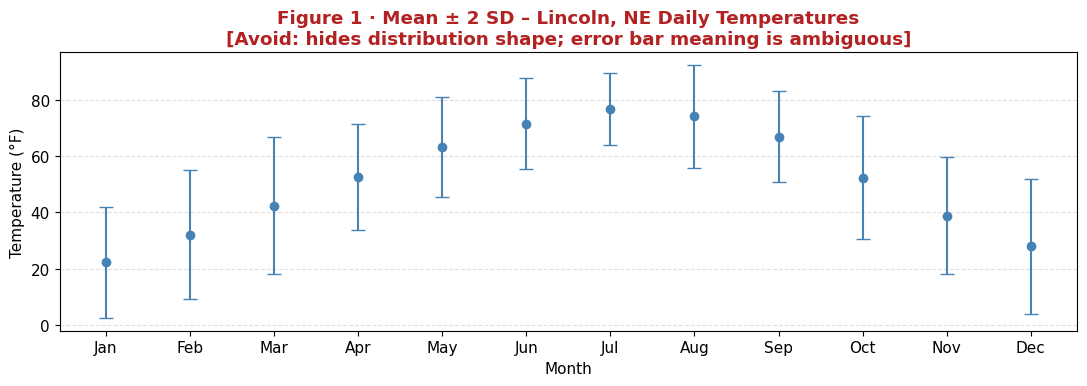

In [21]:
summary = df.groupby("Month", observed=True)["Temp_F"].agg(["mean","std"]).reset_index()

fig, ax = plt.subplots(figsize=(11, 4))
ax.errorbar(summary["Month"], summary["mean"], yerr=2*summary["std"],
            fmt="o", color="steelblue", capsize=5, linewidth=1.5)
ax.set_title(
    "Figure 1 · Mean ± 2 SD – Lincoln, NE Daily Temperatures\n"
    "[Avoid: hides distribution shape; error bar meaning is ambiguous]",
    fontweight="bold", color="firebrick"
)
ax.set_xlabel("Month"); ax.set_ylabel("Temperature (°F)")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("ch9_fig1_errorbar.png", dpi=150, bbox_inches="tight")
plt.show()

## Ch 9 · Figure 2  Boxplots

A **boxplot** shows the median (line), IQR (box), whiskers (1.5×IQR), and outlier points.  
Much more informative than error bars, but still hides multimodality.

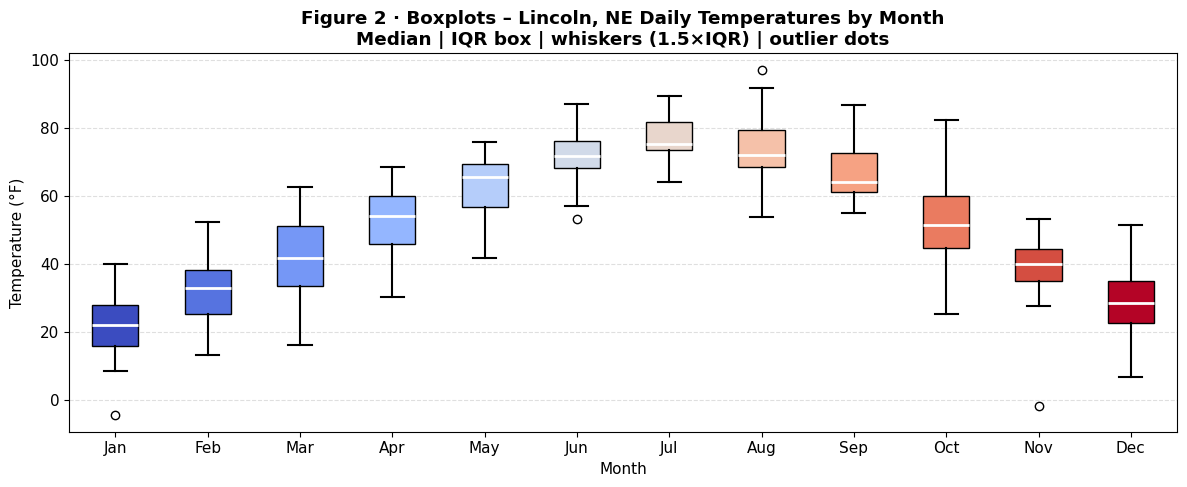

In [22]:
fig, ax = plt.subplots(figsize=(12, 5))
bp = ax.boxplot(grouped, tick_labels=month_order, patch_artist=True,
                medianprops={"color":"white","linewidth":2},
                whiskerprops={"linewidth":1.5}, capprops={"linewidth":1.5})

cmap = plt.cm.coolwarm
for i, patch in enumerate(bp["boxes"]):
    patch.set_facecolor(cmap(i / (len(grouped) - 1)))

ax.set_title(
    "Figure 2 · Boxplots – Lincoln, NE Daily Temperatures by Month\n"
    "Median | IQR box | whiskers (1.5×IQR) | outlier dots",
    fontweight="bold"
)
ax.set_xlabel("Month"); ax.set_ylabel("Temperature (°F)")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("ch9_fig2_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

**Finding:** The seasonal cycle is clear  median temperatures rise from ~24°F in January  
to ~78°F in July, then fall back. IQR boxes are wider in transitional months (March, November),  
reflecting more day-to-day variability.

## Ch 9 · Figure 3  Violin Plots

**Violin plots** show a KDE mirrored around the group axis.  
They reveal **bimodality** and other distributional features that boxplots hide.

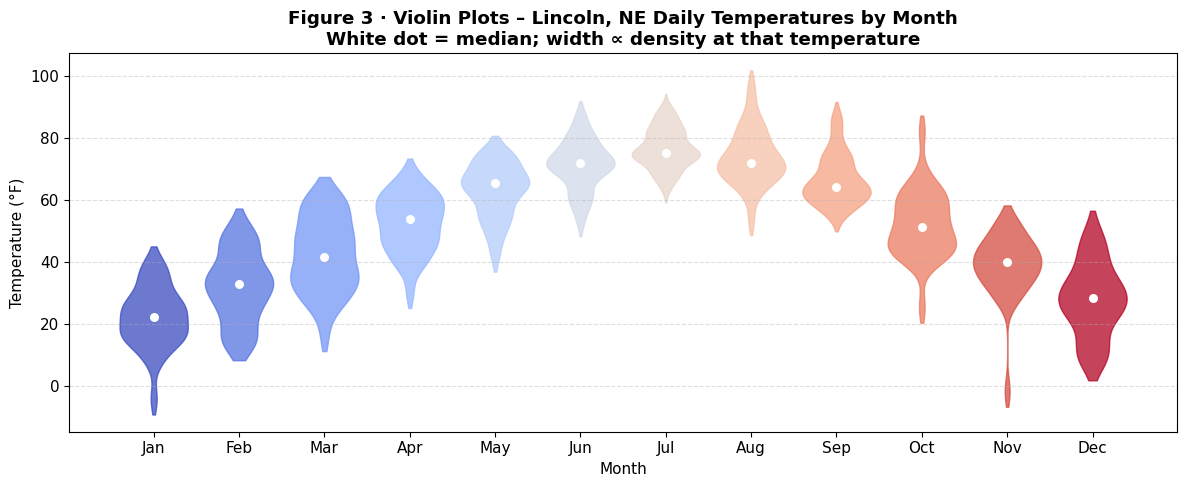

In [23]:
fig, ax = plt.subplots(figsize=(12, 5))

for i, month in enumerate(month_order, start=1):
    data    = df.loc[df["Month"] == month, "Temp_F"].values
    kde     = gaussian_kde(data, bw_method=0.4)
    y_range = np.linspace(data.min() - 5, data.max() + 5, 300)
    density = kde(y_range)
    density = density / density.max() * 0.4
    color   = plt.cm.coolwarm((i - 1) / (len(month_order) - 1))
    ax.fill_betweenx(y_range, i - density, i + density, color=color, alpha=0.75)
    ax.scatter(i, np.median(data), color="white", s=30, zorder=3)

ax.set_xticks(range(1, len(month_order) + 1))
ax.set_xticklabels(month_order)
ax.set_title(
    "Figure 3 · Violin Plots – Lincoln, NE Daily Temperatures by Month\n"
    "White dot = median; width ∝ density at that temperature",
    fontweight="bold"
)
ax.set_xlabel("Month"); ax.set_ylabel("Temperature (°F)")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("ch9_fig3_violin.png", dpi=150, bbox_inches="tight")
plt.show()

**Finding:** Violin plots reveal that November has a slightly bimodal pattern (clusters near 35°F and 50°F),  
suggesting frequent alternation between cold snaps and milder periods  a feature completely hidden  
in the boxplot.

## Ch 9 · Figure 4  Strip Chart: Plain vs Jittered

A **strip chart** plots every raw data point. Plain strips suffer from **overplotting**   
adding random horizontal **jitter** reveals the actual density.

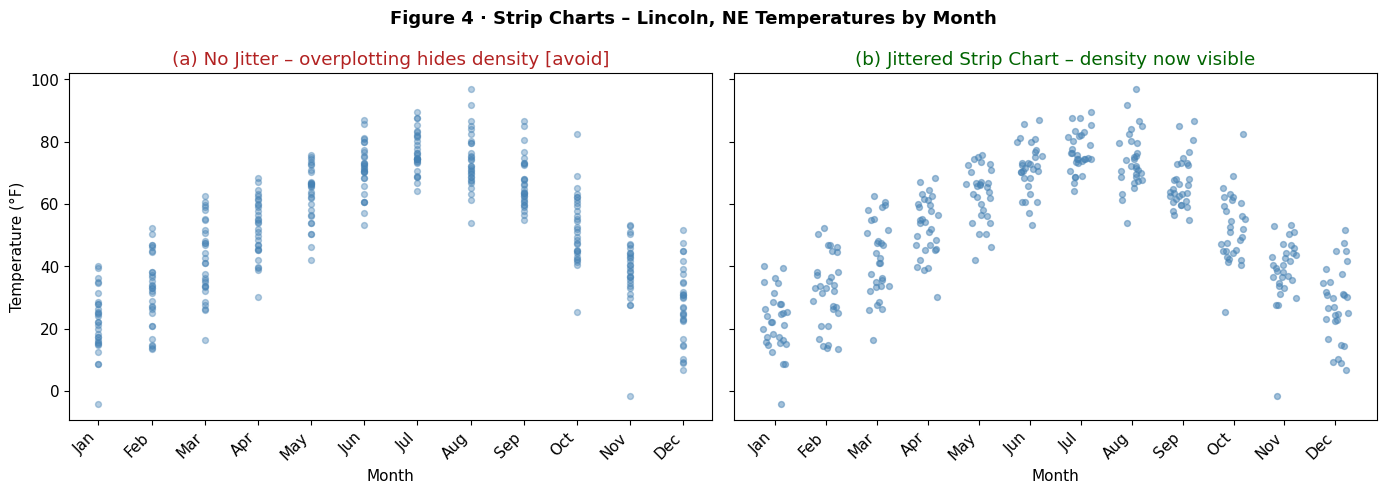

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
fig.suptitle("Figure 4 · Strip Charts – Lincoln, NE Temperatures by Month",
             fontsize=13, fontweight="bold")

for i, month in enumerate(month_order, start=1):
    data   = df.loc[df["Month"] == month, "Temp_F"].values
    jitter = rng.uniform(-0.25, 0.25, size=len(data))
    ax1.scatter(np.full_like(data, i), data, color="steelblue", alpha=0.4, s=18)
    ax2.scatter(i + jitter,            data, color="steelblue", alpha=0.5, s=18)

for ax, title, color in [
    (ax1, "(a) No Jitter – overplotting hides density [avoid]",   "firebrick"),
    (ax2, "(b) Jittered Strip Chart – density now visible",       "darkgreen"),
]:
    ax.set_xticks(range(1, len(month_order) + 1))
    ax.set_xticklabels(month_order, rotation=45, ha="right")
    ax.set_title(title, color=color)
    ax.set_xlabel("Month")
ax1.set_ylabel("Temperature (°F)")

plt.tight_layout()
plt.savefig("ch9_fig4_strip_chart.png", dpi=150, bbox_inches="tight")
plt.show()

## Ch 9 · Figure 5  Sina Plot (Density-Proportional Jitter)

A **sina plot** spreads points horizontally in proportion to the local KDE value   
combining the advantages of violin plots (shows density) and strip charts (shows raw points).

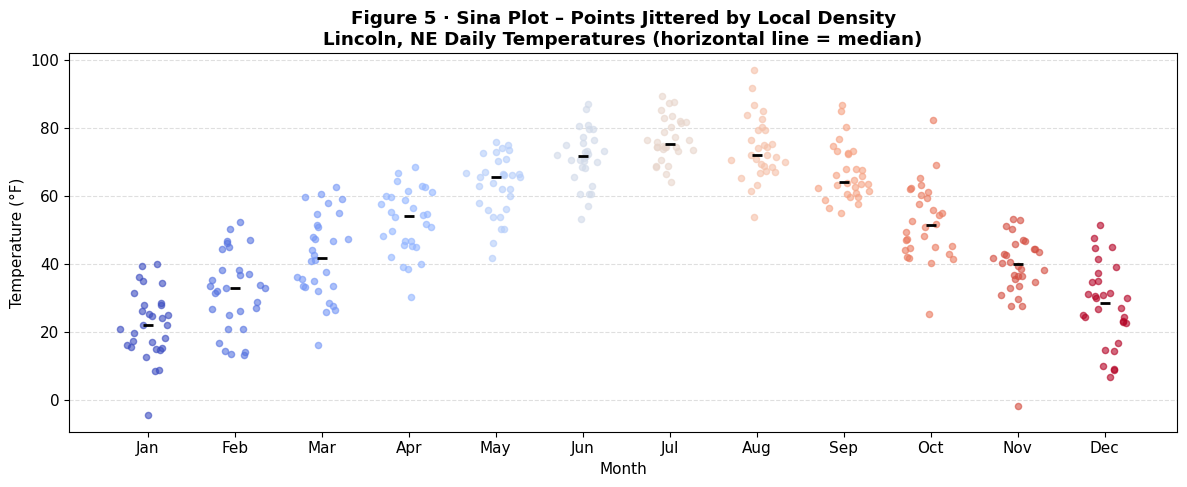

In [25]:
fig, ax = plt.subplots(figsize=(12, 5))

for i, month in enumerate(month_order, start=1):
    data              = df.loc[df["Month"] == month, "Temp_F"].values
    kde               = gaussian_kde(data, bw_method=0.4)
    density_at_points = kde(data)
    density_at_points = density_at_points / density_at_points.max()
    jitter_x          = rng.uniform(-1, 1, size=len(data)) * density_at_points * 0.35
    color             = plt.cm.coolwarm((i - 1) / (len(month_order) - 1))
    ax.scatter(i + jitter_x, data, color=color, alpha=0.6, s=20, zorder=2)
    ax.scatter(i, np.median(data), color="black", s=50, zorder=4, marker="_", linewidths=2)

ax.set_xticks(range(1, len(month_order) + 1))
ax.set_xticklabels(month_order)
ax.set_title(
    "Figure 5 · Sina Plot – Points Jittered by Local Density\n"
    "Lincoln, NE Daily Temperatures (horizontal line = median)",
    fontweight="bold"
)
ax.set_xlabel("Month"); ax.set_ylabel("Temperature (°F)")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig("ch9_fig5_sina_plot.png", dpi=150, bbox_inches="tight")
plt.show()

## Ch 9 · Figure 6  Ridgeline Plot

A **ridgeline plot** stacks KDE distributions along the vertical axis.  
It scales to many groups at once and is especially effective for showing trends over ordered groups.

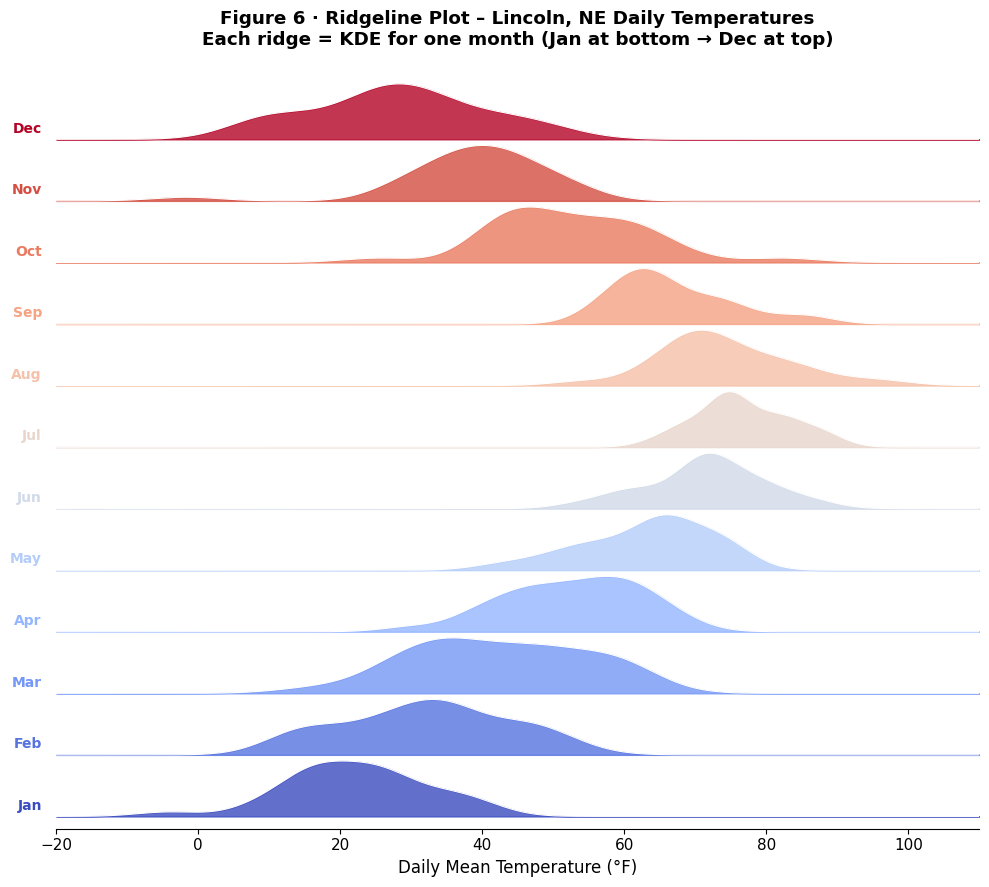

In [26]:
x_range = np.linspace(-20, 110, 500)
overlap  = 2.5
colors   = plt.cm.coolwarm(np.linspace(0, 1, len(month_order)))

fig, ax = plt.subplots(figsize=(10, 9))

for idx, (month, color) in enumerate(zip(month_order, colors)):
    data    = df.loc[df["Month"] == month, "Temp_F"].values
    kde     = gaussian_kde(data, bw_method=0.45)
    density = kde(x_range)
    density = density / density.max() * overlap * 0.9
    baseline = idx * overlap
    ax.fill_between(x_range, baseline, baseline + density,
                    color=color, alpha=0.8, zorder=idx)
    ax.plot(x_range, baseline + density, color="white", linewidth=0.8, zorder=idx + 0.5)
    ax.text(-22, baseline + 0.15, month, ha="right", va="bottom",
            fontsize=10, fontweight="bold", color=color)

ax.set_xlim(-20, 110)
ax.set_ylim(-0.5, len(month_order) * overlap + 1)
ax.set_yticks([])
ax.set_xlabel("Daily Mean Temperature (°F)", fontsize=12)
ax.set_title(
    "Figure 6 · Ridgeline Plot – Lincoln, NE Daily Temperatures\n"
    "Each ridge = KDE for one month (Jan at bottom → Dec at top)",
    fontweight="bold"
)
ax.spines[["left","top","right"]].set_visible(False)
plt.tight_layout()
plt.savefig("ch9_fig6_ridgeline.png", dpi=150, bbox_inches="tight")
plt.show()

**Finding:** The ridgeline plot is the most compact and informative summary of all 12 months.  
The seasonal shift is visually striking  distributions slide from the far-left (cold) in winter  
to the far-right (hot) in summer, with transitional months showing wider, flatter distributions.  
This plot elegantly scales to all 12 groups in a single figure.

## Summary of Key Findings

| Chapter | Key Takeaway |
|---------|-------------|
| **Ch 6** | Use horizontal sorted bars for long labels; dot plots beat bars for narrow data ranges; heatmaps compactly encode two-categorical + quantitative data |
| **Ch 7** | Bin width (histogram) and bandwidth (KDE) dramatically affect perceived distribution shape  always explore several values. Overlapping KDEs are cleaner than overlapping histograms |
| **Ch 8** | ECDFs are parameter-free and let you read percentiles directly. Q-Q plots test distributional assumptions. Right-skewed data should be log-transformed before visualization |
| **Ch 9** | Boxplots summarize quartiles; violin plots reveal full shape and bimodality; sina plots show raw points weighted by density; ridgeline plots scale to many groups at once |